<a href="https://colab.research.google.com/github/davidheram/Times-Series-Forecasting--Water-Detection-System-/blob/main/Sistema_de_Predicci%C3%B3n_del_Nivel_de_Agua_Subterr%C3%A1nea_del_Acu%C3%ADfero_Doganella.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Para este proyecto de series temporales se aplicó el modelo ARIMA al dataset del acuífero Doganella con el objetivo de analizar el comportamiento de la serie, verificar su estacionariedad, seleccionar los parámetros adecuados, entrenar el modelo y generar predicciones futuras.

En este caso se utiliza la variable Depth_to_Groundwater, ya que es una variable continua dependiente del tiempo que representa la evolución del nivel del agua subterránea a lo largo del tiempo.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("/content/Aquifer_Doganella - copia.csv")

In [33]:
df.head()

,Date,Rainfall_Monteporzio,Rainfall_Velletri,Depth_to_Groundwater_Pozzo_1,Depth_to_Groundwater_Pozzo_2,Depth_to_Groundwater_Pozzo_3,Depth_to_Groundwater_Pozzo_4,Depth_to_Groundwater_Pozzo_5,Depth_to_Groundwater_Pozzo_6,Depth_to_Groundwater_Pozzo_7,...,Volume_Pozzo_1,Volume_Pozzo_2,Volume_Pozzo_3,Volume_Pozzo_4,Volume_Pozzo_5+6,Volume_Pozzo_7,Volume_Pozzo_8,Volume_Pozzo_9,Temperature_Monteporzio,Temperature_Velletri
0,01/01/2004,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.30,8.60
1,02/01/2004,0.2,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.70,6.25
2,03/01/2004,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.40,9.80
3,04/01/2004,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.35,5.95
4,05/01/2004,0.2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.60,5.85


In [34]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df = df.sort_values("Date")

df.set_index("Date", inplace=True)

ts = df["Depth_to_Groundwater_Pozzo_1"]

print(ts.head())
print(type(ts.index))

Date
2004-01-01   NaN
2004-01-02   NaN
2004-01-03   NaN
2004-01-04   NaN
2004-01-05   NaN
Name: Depth_to_Groundwater_Pozzo_1, dtype: float64
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


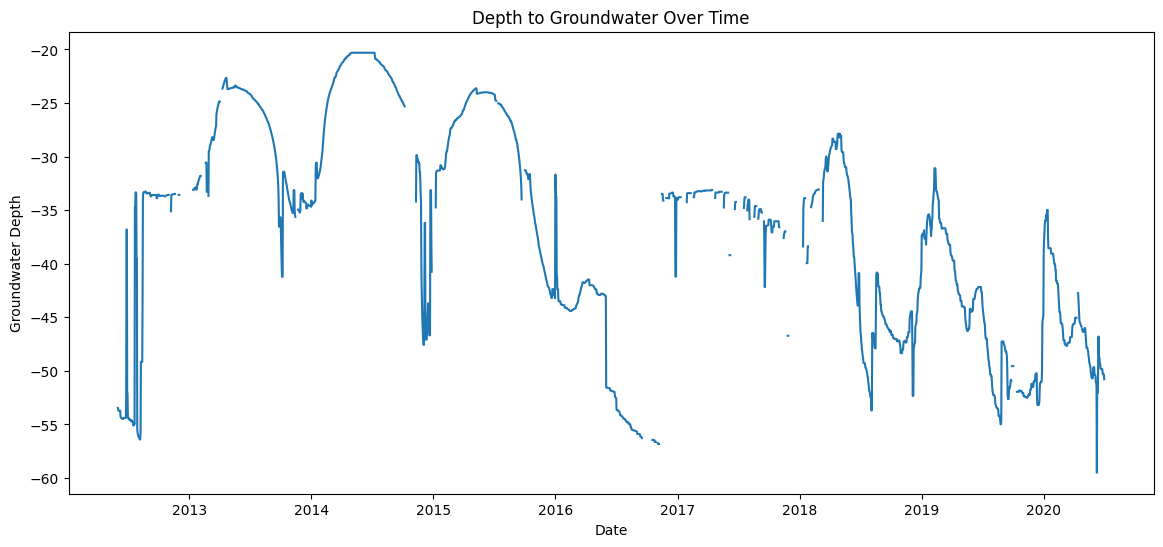

In [35]:

plt.figure(figsize=(14,6))
plt.plot(ts)
plt.title("Depth to Groundwater Over Time")
plt.xlabel("Date")
plt.ylabel("Groundwater Depth")
plt.show()

In [36]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print("Critical Value (%s): %.3f" % (key, value))

ADF Statistic: -2.7014490346087445
p-value: 0.07378785824618599
Critical Value (1%): -3.433
Critical Value (5%): -2.863
Critical Value (10%): -2.567


In [39]:
ts_diff = ts.diff()
ts_diff = ts_diff.dropna()
print(ts_diff.head())



Date
2012-06-02   -0.13
2012-06-03   -0.14
2012-06-04    0.00
2012-06-05    0.00
2012-06-06    0.01
Name: Depth_to_Groundwater_Pozzo_1, dtype: float64


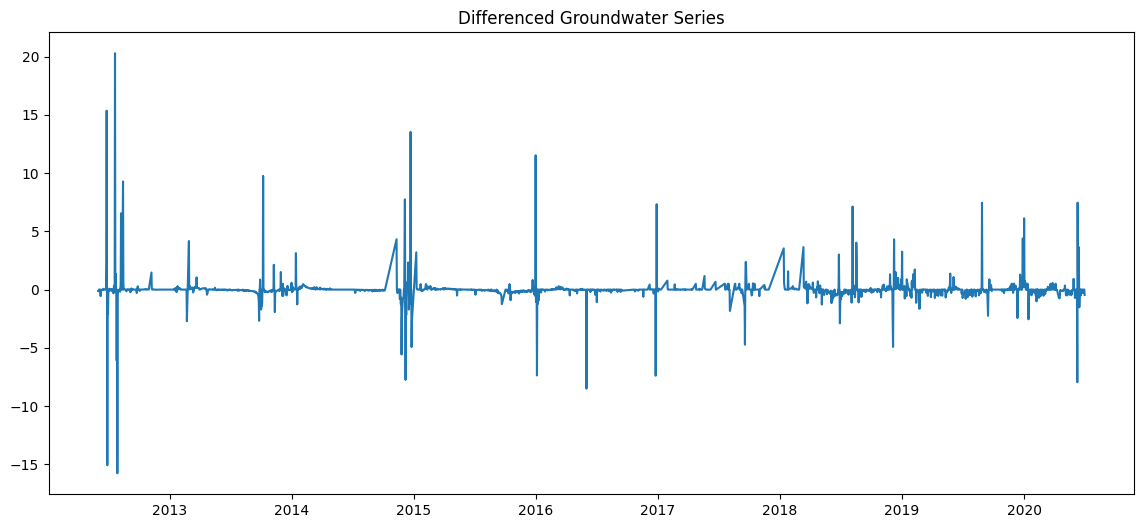

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(ts_diff)
plt.title("Differenced Groundwater Series")
plt.show()

<Figure size 1400x500 with 0 Axes>

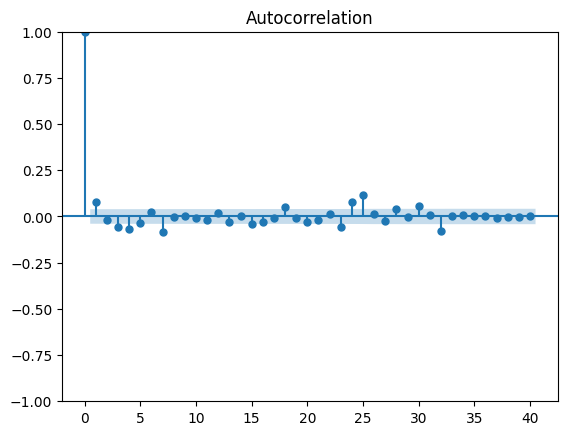

<Figure size 1400x500 with 0 Axes>

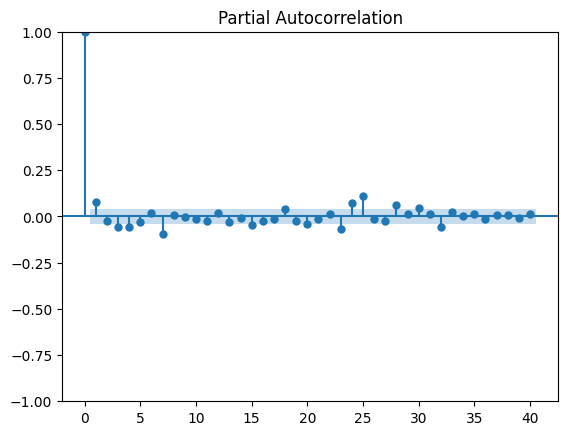

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plot_acf(ts_diff, lags=40)
plt.show()

plt.figure(figsize=(14,5))
plot_pacf(ts_diff, lags=40)
plt.show()

In [42]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                     
Dep. Variable:     Depth_to_Groundwater_Pozzo_1   No. Observations:                 6026
Model:                           ARIMA(1, 1, 1)   Log Likelihood               -3859.835
Date:                          Sun, 01 Mar 2026   AIC                           7725.669
Time:                                  20:04:16   BIC                           7745.780
Sample:                              01-01-2004   HQIC                          7732.652
                                   - 06-30-2020                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0403      0.046      0.869      0.385      -0.051       0.131
ma.L1          0.0609      0.045      1.349      0.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1431: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


In [43]:
model_rw = ARIMA(ts, order=(0,1,0))
model_rw_fit = model_rw.fit()

print(model_rw_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                     
Dep. Variable:     Depth_to_Groundwater_Pozzo_1   No. Observations:                 6026
Model:                           ARIMA(0, 1, 0)   Log Likelihood               -3872.588
Date:                          Sun, 01 Mar 2026   AIC                           7747.177
Time:                                  20:09:11   BIC                           7753.880
Sample:                              01-01-2004   HQIC                          7749.504
                                   - 06-30-2020                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.1920      0.004    282.313      0.000       1.184       1.200
Ljung-Box (L1) (Q):                  41.07   Jarque

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1431: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


In [46]:
forecast = model_fit.forecast(steps=365)

print(forecast.head())

2020-07-01   -50.826546
2020-07-02   -50.828421
2020-07-03   -50.828497
2020-07-04   -50.828500
2020-07-05   -50.828500
Freq: D, Name: predicted_mean, dtype: float64


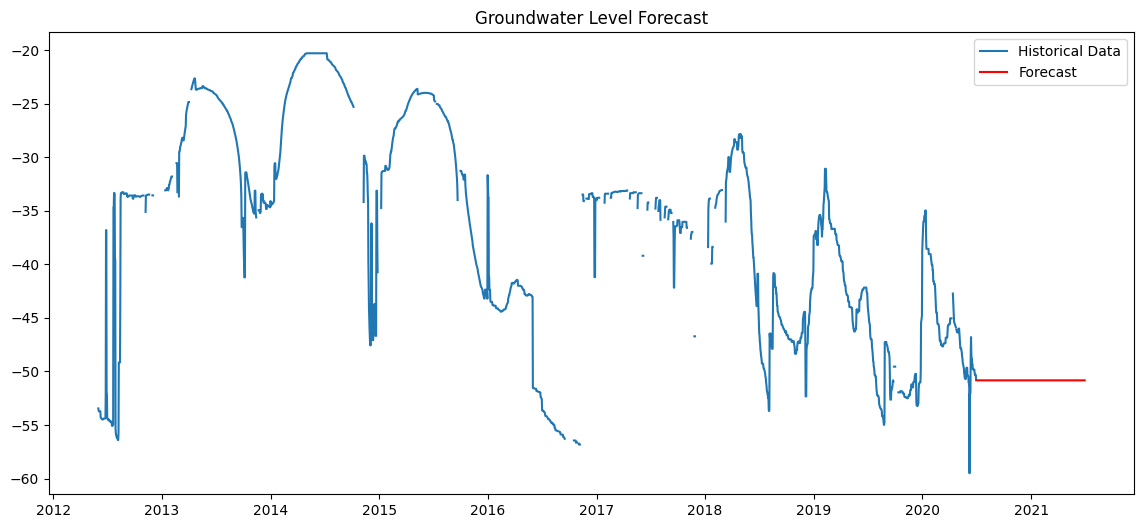

In [47]:
plt.figure(figsize=(14,6))

plt.plot(ts, label="Historical Data")
plt.plot(forecast, label="Forecast", color="red")

plt.title("Groundwater Level Forecast")
plt.legend()
plt.show()

In [48]:
forecast_result = model_fit.get_forecast(steps=365)

forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

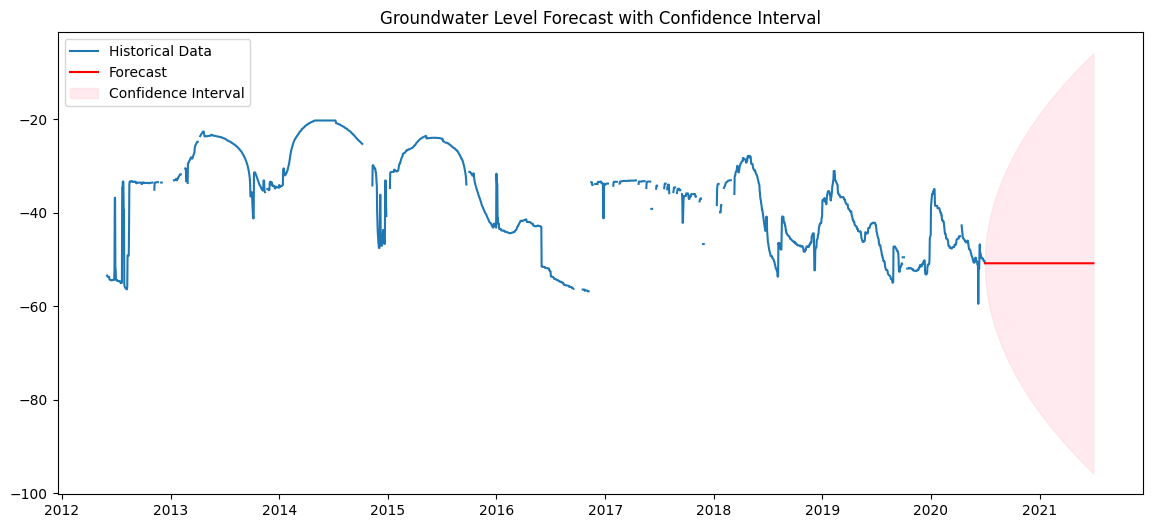

In [49]:
plt.figure(figsize=(14,6))

plt.plot(ts, label="Historical Data")
plt.plot(forecast_mean, label="Forecast", color="red")

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("Groundwater Level Forecast with Confidence Interval")
plt.legend()
plt.show()

En este proyecto se aplicó el modelo ARIMA para analizar y predecir el comportamiento del nivel del agua subterránea del acuífero Doganella. Inicialmente, la serie temporal no era estacionaria debido a la presencia de una tendencia, por lo que fue necesario aplicar una diferenciación para estabilizarla.

A partir del análisis estadístico y de los gráficos ACF y PACF, se seleccionó el modelo ARIMA(1,.1,1) como el más adecuado. El modelo permitió generar predicciones futuras del nivel del acuífero, mostrando un comportamiento coherente con los datos históricos y evidenciando un aumento de la incertidumbre a medida que se extiende el horizonte de predicción.

En conclusión, el modelo ARIMA resultó efectivo para modelar y proyectar la evolución temporal del nivel del agua subterránea.